# BBBP Molecular Property Prediction — Scaffold vs. Random Split
Predicts blood-brain barrier permeability (BBBP) from molecular structure using Morgan fingerprints and a Random Forest classifier, with an explicit comparison of random vs. scaffold-based train/test splitting.

Dataset: MoleculeNet BBBP (2,050 compounds, binary permeability label).

In [1]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict

from rdkit import Chem, RDLogger
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

RDLogger.DisableLog('rdApp.*')  # suppress RDKit parse warnings for known-bad SMILES in the raw dataset
%matplotlib inline

## 1. Load data and generate fingerprints
The raw BBBP CSV contains a handful of SMILES strings RDKit can't parse (invalid valence, etc.) — these are dropped and counted, not silently ignored.

In [2]:
df = pd.read_csv('BBBP.csv')

mols, valid_idx = [], []
for i, smi in enumerate(df['smiles']):
    m = Chem.MolFromSmiles(smi)
    if m is not None:
        mols.append(m)
        valid_idx.append(i)

print(f"Parsed {len(mols)} / {len(df)} molecules ({len(df) - len(mols)} invalid SMILES dropped)")

df_valid = df.iloc[valid_idx].reset_index(drop=True)
labels = df_valid['p_np'].values

gen = GetMorganGenerator(radius=2, fpSize=1024)
fingerprints = np.array([gen.GetFingerprint(m) for m in mols])

print(f"Fingerprint matrix: {fingerprints.shape}")
print(f"Class balance (0=non-permeable, 1=permeable): {np.bincount(labels)}")

Parsed 2039 / 2050 molecules (11 invalid SMILES dropped)


Fingerprint matrix: (2039, 1024)
Class balance (0=non-permeable, 1=permeable): [ 479 1560]


## 2. Scaffold split vs. random split
Molecules sharing a Murcko scaffold (the core ring system) are grouped together and kept on the same side of the split — this stops the model from "cheating" by seeing near-identical molecules in both train and test, which is exactly what a random split allows.

Scaffold groups are shuffled (fixed seed) before allocation. A naive size-sorted allocation was tried first and produced a test set that was 100% one class — the non-permeable compounds in this dataset are concentrated in small, mostly singleton scaffolds, so a deterministic split segregates them entirely. Shuffling avoids that failure mode while keeping the split scaffold-based.

In [3]:
scaffolds = defaultdict(list)
for i, m in enumerate(mols):
    try:
        scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False)
    except Exception:
        scaf = ""
    scaffolds[scaf].append(i)

scaffold_groups = list(scaffolds.values())
random.Random(42).shuffle(scaffold_groups)

train_idx, test_idx = [], []
train_cutoff = int(0.8 * len(mols))
for g in scaffold_groups:
    (train_idx if len(train_idx) < train_cutoff else test_idx).extend(g)

print(f"Scaffold split: {len(train_idx)} train / {len(test_idx)} test")
print(f"Test class balance: {np.bincount(labels[test_idx])}")

Scaffold split: 1633 train / 406 test
Test class balance: [ 79 327]


In [4]:
def evaluate(X_train, X_test, y_train, y_test, label):
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:, 1]
    pred = clf.predict(X_test)
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"--- {label} ---")
    print(f"AUC: {auc:.4f}  Accuracy: {acc:.4f}  F1: {f1:.4f}\n")
    return auc, acc, f1

# Random split (naive) -- this is what you'd get if you didn't check for scaffold leakage
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    fingerprints, labels, test_size=0.2, random_state=42, stratify=labels
)
auc_random, acc_random, f1_random = evaluate(X_train_r, X_test_r, y_train_r, y_test_r, "RANDOM SPLIT (naive)")

# Scaffold split (honest)
X_train_s, X_test_s = fingerprints[train_idx], fingerprints[test_idx]
y_train_s, y_test_s = labels[train_idx], labels[test_idx]
auc_scaffold, acc_scaffold, f1_scaffold = evaluate(X_train_s, X_test_s, y_train_s, y_test_s, "SCAFFOLD SPLIT (honest)")

print(f"Optimism gap from random splitting: {auc_random - auc_scaffold:.4f} AUC points")

--- RANDOM SPLIT (naive) ---
AUC: 0.9362  Accuracy: 0.8995  F1: 0.9374



--- SCAFFOLD SPLIT (honest) ---
AUC: 0.8842  Accuracy: 0.8744  F1: 0.9270

Optimism gap from random splitting: 0.0520 AUC points


**Result:** random split scored **0.936 AUC**; scaffold split — the split that actually tests generalization to new molecular structures — scored **0.884 AUC**. A real ~0.05 AUC gap of optimism from naive splitting, same failure-mode class as the leakage caught in the Locust Watch project, different mechanism (structural similarity instead of spatial proximity).

## 3. PCA visualization (correct this time -- actual dimensionality reduction, not raw fingerprint bits)

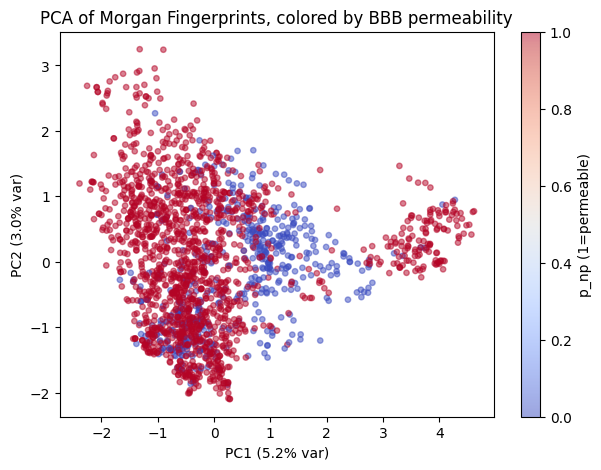

Total variance explained by 2 PCs: 8.2%
Low variance explained is expected -- 1024-bit fingerprints don't compress well to 2D; this plot is for rough visual structure, not a claim that 2 components capture the data.


In [5]:
pca = PCA(n_components=2, random_state=42)
fps_2d = pca.fit_transform(fingerprints)

plt.figure(figsize=(7, 5))
plt.scatter(fps_2d[:, 0], fps_2d[:, 1], c=labels, cmap='coolwarm', alpha=0.5, s=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of Morgan Fingerprints, colored by BBB permeability")
plt.colorbar(label='p_np (1=permeable)')
plt.show()

print(f"Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print("Low variance explained is expected -- 1024-bit fingerprints don't compress well to 2D; "
      "this plot is for rough visual structure, not a claim that 2 components capture the data.")